# Section 1: Dataset

Swimming has always been a huge part of my life. I started swimming competitively in first grade, and now I am part of the Illini Swim Club! So, I decided to choose a swimming related dataset, and I found one online from `https://data.scorenetwork.org/swimming/olympic_swimming_history.html` that contains Olympic swimming data from 1912 to 2020. I would like to discover what trends there are in how much faster swimmers are becoming, the performance of each country, and the differences in time between male and female swimmers throughout the years. I will store this in df_original, and it has 4359 rows and 10 columns. The variables are: 

Location: The hosting city of the Olympics that the swimmer competed in

Year: Year that the swimmer competed

Distance (in meters): Distance in meters of the race (relays are formatted as how much distance each swimmer swims - i.e. 4x100)

Stroke: The stroke the event is in (Backstroke, Breastroke, Butterfly, or Freestyle)

Relay?: 0 (Individual) or 1 (Relay)

Gender: Gender of swimmer (Men or Women)

Team: 3 letter country code the swimmer is affiliated with

Athlete: First and last name of the swimmer

Results: Time the swimmer took to complete the race (minutes:seconds.decimal)

Rank: 0 (Did not start or disqualified), 1 (Gold), 2 (Silver), 3 (Bronze), 4 (No medal), 5 (No data)

However, to make things simpler, I will only focus on the 100m events. So, I will use a filtered version of this dataset that only includes 100m events. This dataset, stored in df, has 1235 rows and 10 columns.

In [2]:
import pandas as pd
#load the dataset
pd.reset_option('display.max_rows')
df_original = pd.read_csv("olympic_swim.csv")
df_original

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4
...,...,...,...,...,...,...,...,...,...,...
4354,Stockholm,1912,4x100,Freestyle,1,Women,SWE,"Greta Carlsson, Vera Thulin, Sonja Johnsson, G...",NaN,5
4355,Stockholm,1912,4x200,Freestyle,1,Men,AUS,"Malcolm Champion, Cecil Healy, Harold H. Hardw...",00:10:11.200000,1
4356,Stockholm,1912,4x200,Freestyle,1,Men,USA,"Duke Paoa Kahanamoku, Harry J. Hebner, Perry M...",00:10:20.200000,2
4357,Stockholm,1912,4x200,Freestyle,1,Men,GBR,"Thomas Sidney Battersby, Henry Taylor, John Ga...",00:10:28.600000,3


In [3]:
df = df_original[df_original["Distance (in meters)"] == "100m"].reset_index().drop("index", axis=1)
df

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4
...,...,...,...,...,...,...,...,...,...,...
1230,Stockholm,1912,100m,Freestyle,0,Women,GBR,Jennie Fletcher,00:01:27.000000,3
1231,Stockholm,1912,100m,Freestyle,0,Women,GER,Grete Rosenberg,00:01:27.200000,4
1232,Stockholm,1912,100m,Freestyle,0,Women,GBR,Annie Speirs,00:01:27.400000,4
1233,Stockholm,1912,100m,Freestyle,0,Women,GBR,Irene Steer,Disqualified,0


In [4]:
#number of rows
len(df)

1235

In [5]:
#column names
df.columns

Index(['Location', 'Year', 'Distance (in meters)', 'Stroke', 'Relay?',
       'Gender', 'Team', 'Athlete', 'Results', 'Rank'],
      dtype='object')

# Section 2: Exploratory Data Analysis

Descriptive statistics that will give me a broad overview of the data:
- Number of men and number of women in the dataset
- Number of countries and how many gold medals they won
- Total number of entries for each stroke/event (100 back, 100 breast, 100 fly, 100 free)
- Average male and female time for each event
- Average timed results for each year

#### Part 2.1: Total Number of Men and Total Number of Women by Year

In [6]:
df_num_gender = df.groupby(["Year", "Gender"]).agg("count").reset_index()
df_num_gender

,Year,Gender,Location,Distance (in meters),Stroke,Relay?,Team,Athlete,Results,Rank
0,1912,Men,16,16,16,16,16,16,16,16
1,1912,Women,7,7,7,7,7,7,7,7
2,1920,Men,10,10,10,10,10,10,9,10
3,1920,Women,7,7,7,7,7,7,5,7
4,1924,Men,15,15,15,15,15,15,15,15
5,1924,Women,14,14,14,14,14,14,14,14
6,1928,Men,16,16,16,16,16,16,16,16
7,1928,Women,16,16,16,16,16,16,16,16
8,1932,Men,16,16,16,16,16,16,16,16
9,1932,Women,14,14,14,14,14,14,14,14


From this, we can see that the number of men and women competitors eventually was standardized starting in 1968 so that there would be the same number of female and male competitors each year for the 100m events. I am surprised to see that there isn't as large of a difference in the number of male and female swimmers even starting from 1912. In fact, from 1956 to 1964, there were more female swimmers in 100m events than male swimmers.

#### Part 2.2: Number of Countries and Number of Gold Medals by Country

In [7]:
df_countries = df.groupby("Team").agg("count").reset_index()
df_countries

,Team,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Athlete,Results,Rank
0,ALG,1,1,1,1,1,1,1,1,1
1,ANZ,3,3,3,3,3,3,3,3,3
2,ARG,9,9,9,9,9,9,9,9,9
3,AUS,119,119,119,119,119,119,119,119,119
4,AUT,4,4,4,4,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...
60,URU,1,1,1,1,1,1,1,1,1
61,USA,298,298,298,298,298,298,298,296,298
62,VEN,3,3,3,3,3,3,3,3,3
63,YUG,3,3,3,3,3,3,3,3,3


In [8]:
#Top 5 countries with the most swimmers
df_countries.nlargest(5, "Year")

,Team,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Athlete,Results,Rank
61,USA,298,298,298,298,298,298,298,296,298
3,AUS,119,119,119,119,119,119,119,119,119
23,GBR,73,73,73,73,73,73,73,73,73
41,NED,68,68,68,68,68,68,68,68,68
35,JPN,61,61,61,61,61,61,61,61,61


In [9]:
#Countries with only 1 swimmer
df_countries[df_countries.Year == 1]

,Team,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Athlete,Results,Rank
0,ALG,1,1,1,1,1,1,1,1,1
11,COL,1,1,1,1,1,1,1,1,1
15,CZE,1,1,1,1,1,1,1,1,1
17,EGY,1,1,1,1,1,1,1,1,1
26,GRE,1,1,1,1,1,1,1,1,1
27,GUA,1,1,1,1,1,1,1,1,1
28,HKG,1,1,1,1,1,1,1,1,1
30,IRL,1,1,1,1,1,1,1,1,1
31,ISL,1,1,1,1,1,1,1,1,1
37,KEN,1,1,1,1,1,1,1,1,1


In [10]:
#Filtering the dataframe to only be swimmers that placed gold
df_gold = df[df.Rank == 1]
df_gold

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1
8,Tokyo,2020,100m,Breaststroke,0,Men,GBR,Adam Peaty,57.37,1
16,Tokyo,2020,100m,Butterfly,0,Men,USA,Caeleb Dressel,49.45,1
24,Tokyo,2020,100m,Freestyle,0,Men,USA,Caeleb Dressel,47.02,1
32,Tokyo,2020,100m,Backstroke,0,Women,AUS,Kaylee Mckeown,57.47,1
...,...,...,...,...,...,...,...,...,...,...
1187,Paris,1924,100m,Freestyle,0,Women,USA,Ethel Lackie,00:01:12.400000,1
1200,Antwerp,1920,100m,Freestyle,0,Men,USA,Duke Paoa Kahanamoku,00:01:01.400000,1
1212,Stockholm,1912,100m,Backstroke,0,Men,USA,Harry J. Hebner,00:01:21.200000,1
1220,Stockholm,1912,100m,Freestyle,0,Men,USA,Duke Paoa Kahanamoku,00:01:03.400000,1


In [11]:
#Group by Team to see how many gold medals each country has won
df_gold.groupby("Team").agg("count").reset_index()

,Team,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Athlete,Results,Rank
0,ANZ,1,1,1,1,1,1,1,1,1
1,AUS,14,14,14,14,14,14,14,14,14
2,BEL,1,1,1,1,1,1,1,1,1
3,BUL,1,1,1,1,1,1,1,1,1
4,CAN,3,3,3,3,3,3,3,3,3
5,CHN,3,3,3,3,3,3,3,3,3
6,DEN,2,2,2,2,2,2,2,2,2
7,EGY,1,1,1,1,1,1,1,1,1
8,EUN,2,2,2,2,2,2,2,2,2
9,FRA,2,2,2,2,2,2,2,2,2


From the results above, we can see that Team USA has had the most swimmers compete in the 100m events from 1912 to 2020, which is unsurprising. The second team with the most swimmers in the 100m events is Australia, followed by Great Britain, the Netherlands, and then Japan.
There are 14 countries that have only had 1 swimmer compete in a 100m event. In addition, the USA has won the most gold medals with 67 gold medals, followed by Australia with 14 gold medals.

#### Part 2.3: Total Number of Entries for Each Event

In [12]:
df_num_strokes = df.groupby("Stroke").agg("count").reset_index()
df_num_strokes

,Stroke,Location,Year,Distance (in meters),Relay?,Gender,Team,Athlete,Results,Rank
0,Backstroke,371,371,371,371,371,371,371,370,371
1,Breaststroke,224,224,224,224,224,224,224,222,224
2,Butterfly,248,248,248,248,248,248,248,247,248
3,Freestyle,392,392,392,392,392,392,392,390,392


From this, we can see that Freestyle is the most popular of the strokes for 100m events. The least popular is Breastroke.

#### Part 2.4: Average Male and Female Times for Each Year for Each Event
To do this, I will first need to convert all the times into the same units so that they will be easier to average. I will convert the times all into seconds using a function. There are also results such as "Disqualified" or "Did not finish", so I will set them equal to 0 and then filter them out so that they will have no effect when averaging the data.

In [46]:
#Displaying df for reference
df

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1,51.98
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2,52.00
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3,52.19
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4,52.30
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4,52.51
...,...,...,...,...,...,...,...,...,...,...,...
1230,Stockholm,1912,100m,Freestyle,0,Women,GBR,Jennie Fletcher,00:01:27.000000,3,87.00
1231,Stockholm,1912,100m,Freestyle,0,Women,GER,Grete Rosenberg,00:01:27.200000,4,87.20
1232,Stockholm,1912,100m,Freestyle,0,Women,GBR,Annie Speirs,00:01:27.400000,4,87.40
1233,Stockholm,1912,100m,Freestyle,0,Women,GBR,Irene Steer,Disqualified,0,0.00


Below is my function for converting the results into seconds.

In [14]:
def convert(row):
    try: 
        time = float(row["Results"]) #convert result to float
    except: #if result is not in a float format, an error will occur when converting to a float
        if ":" in row["Results"]: #for times >= 1 minute, substring the result to only have the seconds part
            time = 60.0 + float(row["Results"][6:]) #add 60 seconds (for 100m events, all times are guaranteed less than 1 minute)
        else: #if the result is something like "Disqualified" or "Did not finish",
            time = 0.0
    return time 

In [15]:
df["Time"] = df.apply(convert, axis=1)
df

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1,51.98
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2,52.00
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3,52.19
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4,52.30
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4,52.51
...,...,...,...,...,...,...,...,...,...,...,...
1230,Stockholm,1912,100m,Freestyle,0,Women,GBR,Jennie Fletcher,00:01:27.000000,3,87.00
1231,Stockholm,1912,100m,Freestyle,0,Women,GER,Grete Rosenberg,00:01:27.200000,4,87.20
1232,Stockholm,1912,100m,Freestyle,0,Women,GBR,Annie Speirs,00:01:27.400000,4,87.40
1233,Stockholm,1912,100m,Freestyle,0,Women,GBR,Irene Steer,Disqualified,0,0.00


In [45]:
#Filter out the times that equal 0.0 (otherwise, they will impact the averages a lot because 0.0 seconds is an insanely fast time!) and NaN values
df_filtered_times = df[df.Time != 0.00]
df_filtered_times = df_filtered_times.dropna()
df_filtered_times

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1,51.98
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2,52.00
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3,52.19
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4,52.30
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4,52.51
...,...,...,...,...,...,...,...,...,...,...,...
1228,Stockholm,1912,100m,Freestyle,0,Women,ANZ,Fanny Durack,00:01:22.200000,1,82.20
1229,Stockholm,1912,100m,Freestyle,0,Women,ANZ,Mina Wylie,00:01:25.400000,2,85.40
1230,Stockholm,1912,100m,Freestyle,0,Women,GBR,Jennie Fletcher,00:01:27.000000,3,87.00
1231,Stockholm,1912,100m,Freestyle,0,Women,GER,Grete Rosenberg,00:01:27.200000,4,87.20


Now that I have a filtered dataset that has timed results for each swimmer in seconds, I will group the dataset by gender.

In [17]:
df_female = df_filtered_times[df_filtered_times.Gender == "Women"]
df_female

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time
32,Tokyo,2020,100m,Backstroke,0,Women,AUS,Kaylee Mckeown,57.47,1,57.47
33,Tokyo,2020,100m,Backstroke,0,Women,CAN,Kylie Masse,57.72,2,57.72
34,Tokyo,2020,100m,Backstroke,0,Women,USA,Regan Smith,58.05,3,58.05
35,Tokyo,2020,100m,Backstroke,0,Women,USA,Rhyan Elizabeth White,58.43,4,58.43
36,Tokyo,2020,100m,Backstroke,0,Women,AUS,Emily Seebohm,58.45,4,58.45
...,...,...,...,...,...,...,...,...,...,...,...
1228,Stockholm,1912,100m,Freestyle,0,Women,ANZ,Fanny Durack,00:01:22.200000,1,82.20
1229,Stockholm,1912,100m,Freestyle,0,Women,ANZ,Mina Wylie,00:01:25.400000,2,85.40
1230,Stockholm,1912,100m,Freestyle,0,Women,GBR,Jennie Fletcher,00:01:27.000000,3,87.00
1231,Stockholm,1912,100m,Freestyle,0,Women,GER,Grete Rosenberg,00:01:27.200000,4,87.20


In [18]:
df_male = df_filtered_times[df_filtered_times.Gender == "Men"]
df_male

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1,51.98
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2,52.00
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3,52.19
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4,52.30
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4,52.51
...,...,...,...,...,...,...,...,...,...,...,...
1220,Stockholm,1912,100m,Freestyle,0,Men,USA,Duke Paoa Kahanamoku,00:01:03.400000,1,63.40
1221,Stockholm,1912,100m,Freestyle,0,Men,ANZ,Cecil Healy,00:01:04.600000,2,64.60
1222,Stockholm,1912,100m,Freestyle,0,Men,USA,Kenneth Huszagh,00:01:05.600000,3,65.60
1223,Stockholm,1912,100m,Freestyle,0,Men,GER,Kurt Bretting,00:01:05.800000,4,65.80


Next, after grouping by gender, I will group by Stroke and Year and find the mean of the times.

In [19]:
df_fem_av_times = df_female[["Stroke", "Year", "Time"]].groupby(["Stroke", "Year"]).agg("mean", numeric_only=True).reset_index()
df_fem_av_times

,Stroke,Year,Time
0,Backstroke,1924,88.160000
1,Backstroke,1928,83.685714
2,Backstroke,1932,82.066667
3,Backstroke,1936,79.942857
4,Backstroke,1948,77.662500
...,...,...,...
74,Freestyle,2004,54.576250
75,Freestyle,2008,53.801250
76,Freestyle,2012,53.545000
77,Freestyle,2016,53.051250


Now, I will filter the df_fem_av_times dataframe to each specific stroke for a more accurate and logical comparison.

In [20]:
#Freestyle
df_fem_free = df_fem_av_times[df_fem_av_times.Stroke == "Freestyle"]
df_fem_free

,Stroke,Year,Time
54,Freestyle,1912,85.840000
55,Freestyle,1920,77.650000
56,Freestyle,1924,75.120000
57,Freestyle,1928,73.266667
58,Freestyle,1932,68.800000
59,Freestyle,1936,67.385714
60,Freestyle,1948,67.900000
61,Freestyle,1952,67.375000
62,Freestyle,1956,64.625000
63,Freestyle,1960,63.575000


In [21]:
#Backstroke
df_fem_back = df_fem_av_times[df_fem_av_times.Stroke == "Backstroke"]
df_fem_back

,Stroke,Year,Time
0,Backstroke,1924,88.160000
1,Backstroke,1928,83.685714
2,Backstroke,1932,82.066667
3,Backstroke,1936,79.942857
4,Backstroke,1948,77.662500
5,Backstroke,1952,76.142857
6,Backstroke,1956,73.712500
7,Backstroke,1960,71.325000
8,Backstroke,1964,69.012500
9,Backstroke,1968,68.425000


In [22]:
#Butterfly
df_fem_fly = df_fem_av_times[df_fem_av_times.Stroke == "Butterfly"]
df_fem_fly

,Stroke,Year,Time
37,Butterfly,1956,75.137500
38,Butterfly,1960,72.228571
39,Butterfly,1964,67.400000
40,Butterfly,1968,66.562500
41,Butterfly,1972,63.886250
42,Butterfly,1976,61.461250
43,Butterfly,1980,61.971250
44,Butterfly,1984,61.222500
45,Butterfly,1988,60.096250
46,Butterfly,1992,59.605000


In [23]:
#Breaststroke
df_fem_breast = df_fem_av_times[df_fem_av_times.Stroke == "Breaststroke"]
df_fem_breast

,Stroke,Year,Time
23,Breaststroke,1968,76.525000
24,Breaststroke,1972,76.092500
25,Breaststroke,1976,73.445000
26,Breaststroke,1980,71.477500
27,Breaststroke,1984,70.986250
28,Breaststroke,1988,69.302500
29,Breaststroke,1992,69.566250
30,Breaststroke,1996,69.023750
31,Breaststroke,2000,68.168750
32,Breaststroke,2004,67.385714


In [24]:
#Doing all the steps above, but for males
df_male_av_times = df_male[["Stroke", "Year", "Time"]].groupby(["Stroke", "Year"]).agg("mean", numeric_only=True).reset_index()
df_male_av_times

,Stroke,Year,Time
0,Backstroke,1912,83.720000
1,Backstroke,1920,77.600000
2,Backstroke,1924,77.200000
3,Backstroke,1928,72.166667
4,Backstroke,1932,70.566667
...,...,...,...
72,Freestyle,2004,48.801250
73,Freestyle,2008,47.773750
74,Freestyle,2012,47.871250
75,Freestyle,2016,47.958750


In [25]:
#Freestyle
df_male_free = df_male_av_times[df_male_av_times.Stroke == "Freestyle"]
df_male_free

,Stroke,Year,Time
52,Freestyle,1912,65.160000
53,Freestyle,1920,62.700000
54,Freestyle,1924,61.440000
55,Freestyle,1928,60.457143
56,Freestyle,1932,58.916667
57,Freestyle,1936,58.642857
58,Freestyle,1948,58.650000
59,Freestyle,1952,58.287500
60,Freestyle,1956,57.050000
61,Freestyle,1960,55.912500


In [26]:
#Backstroke
df_male_back = df_male_av_times[df_male_av_times.Stroke == "Backstroke"]
df_male_back

,Stroke,Year,Time
0,Backstroke,1912,83.720000
1,Backstroke,1920,77.600000
2,Backstroke,1924,77.200000
3,Backstroke,1928,72.166667
4,Backstroke,1932,70.566667
5,Backstroke,1936,68.885714
6,Backstroke,1948,68.325000
7,Backstroke,1952,67.187500
8,Backstroke,1956,64.762500
9,Backstroke,1960,63.150000


In [27]:
#Butterfly
df_male_fly = df_male_av_times[df_male_av_times.Stroke == "Butterfly"]
df_male_fly

,Stroke,Year,Time
38,Butterfly,1968,57.96250
39,Butterfly,1972,56.26500
40,Butterfly,1976,55.30250
41,Butterfly,1980,55.29625
42,Butterfly,1984,54.21625
43,Butterfly,1988,53.60500
44,Butterfly,1992,53.82000
45,Butterfly,1996,53.07875
46,Butterfly,2000,52.53250
47,Butterfly,2004,51.98125


In [28]:
#Breaststroke
df_male_breast = df_male_av_times[df_male_av_times.Stroke == "Breaststroke"]
df_male_breast

,Stroke,Year,Time
24,Breaststroke,1968,68.400000
25,Breaststroke,1972,65.917500
26,Breaststroke,1976,64.196250
27,Breaststroke,1980,64.391429
28,Breaststroke,1984,63.087500
29,Breaststroke,1988,62.510000
30,Breaststroke,1992,61.923750
31,Breaststroke,1996,61.463750
32,Breaststroke,2000,61.253750
33,Breaststroke,2004,61.145000


From df_fem_av_times and df_male_av_times, we can see that there are signficant decreases in the average times for each event from 1912 to 2020 for each 100m event. For example, just looking at the 100m Freestyle, we can see that for females, there is more than a 30 second difference in the time for 1912 and 2020. For males, there is almost a 20 second difference in the 100m Freestyle times for 1912 and 2020.

#### Part 2.5: Average Timed Results for Each Year by Event
In Part 2.4, I did a more detailed breakdown of the average times by gender, but here I was curious to see the general trend of average times for events (regardless of gender).

In [29]:
df_av_times = df_filtered_times[["Year", "Stroke", "Time"]].groupby(["Year", "Stroke"]).agg("mean", numeric_only=True).reset_index()
df_av_times

,Year,Stroke,Time
0,1912,Backstroke,83.720000
1,1912,Freestyle,75.500000
2,1920,Backstroke,77.600000
3,1920,Freestyle,70.175000
4,1924,Backstroke,82.680000
...,...,...,...
76,2016,Freestyle,50.505000
77,2020,Backstroke,55.435000
78,2020,Breaststroke,61.365000
79,2020,Butterfly,53.393750


In [30]:
df_av_times_free = df_av_times[df_av_times.Stroke == "Freestyle"]
df_av_times_free

,Year,Stroke,Time
1,1912,Freestyle,75.500000
3,1920,Freestyle,70.175000
5,1924,Freestyle,68.280000
7,1928,Freestyle,66.369231
9,1932,Freestyle,63.858333
11,1936,Freestyle,63.014286
13,1948,Freestyle,63.275000
15,1952,Freestyle,62.831250
18,1956,Freestyle,60.837500
21,1960,Freestyle,59.743750


In [31]:
df_av_times_back = df_av_times[df_av_times.Stroke == "Backstroke"]
df_av_times_back

,Year,Stroke,Time
0,1912,Backstroke,83.720000
2,1920,Backstroke,77.600000
4,1924,Backstroke,82.680000
6,1928,Backstroke,78.369231
8,1932,Backstroke,76.316667
10,1936,Backstroke,74.414286
12,1948,Backstroke,72.993750
14,1952,Backstroke,71.366667
16,1956,Backstroke,69.237500
19,1960,Backstroke,67.237500


In [32]:
df_av_times_fly = df_av_times[df_av_times.Stroke == "Butterfly"]
df_av_times_fly

,Year,Stroke,Time
17,1956,Butterfly,75.137500
20,1960,Butterfly,72.228571
23,1964,Butterfly,67.400000
27,1968,Butterfly,62.262500
31,1972,Butterfly,60.075625
35,1976,Butterfly,58.381875
39,1980,Butterfly,58.633750
43,1984,Butterfly,57.719375
47,1988,Butterfly,56.850625
51,1992,Butterfly,56.712500


In [33]:
df_av_times_breast = df_av_times[df_av_times.Stroke == "Breaststroke"]
df_av_times_breast

,Year,Stroke,Time
26,1968,Breaststroke,72.462500
30,1972,Breaststroke,71.005000
34,1976,Breaststroke,68.820625
38,1980,Breaststroke,68.170667
42,1984,Breaststroke,67.036875
46,1988,Breaststroke,65.906250
50,1992,Breaststroke,65.745000
54,1996,Breaststroke,65.243750
58,2000,Breaststroke,64.711250
62,2004,Breaststroke,64.057333


For the 100m event for all four strokes, the average time across the years has all decreased.

## Section 3: Exploratory Data Visualization

#### Part 3.1: Graph of 100m Freestyle Times from 1912-2020 by Gender

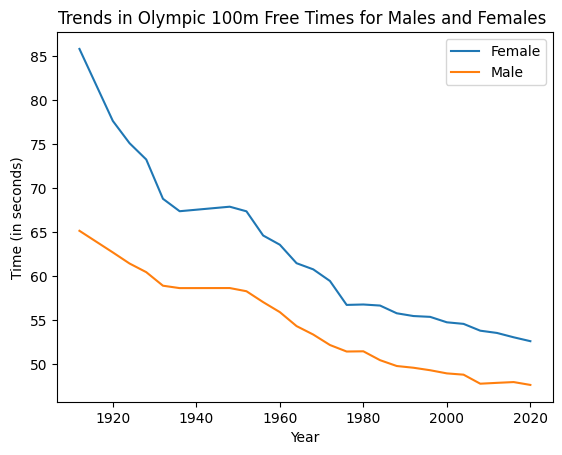

In [34]:
ax = df_fem_free.plot.line(x="Year", y="Time")
df_male_free.plot.line(x="Year", y="Time", ax=ax)
ax.set_ylabel("Time (in seconds)")
ax.set_title("Trends in Olympic 100m Free Times for Males and Females ")
ax.legend(["Female", "Male"])

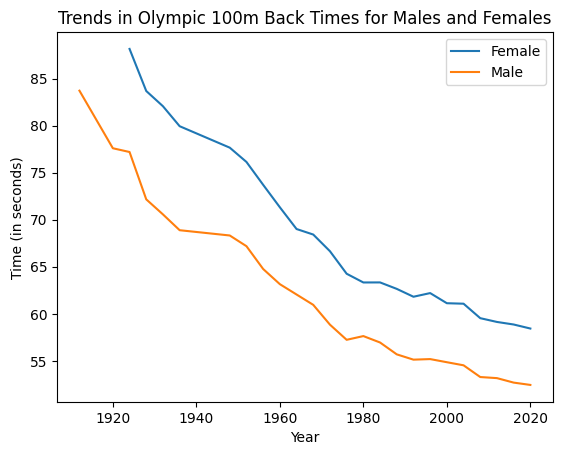

In [35]:
ax = df_fem_back.plot.line(x="Year", y="Time")
df_male_back.plot.line(x="Year", y="Time", ax=ax)
ax.set_ylabel("Time (in seconds)")
ax.set_title("Trends in Olympic 100m Back Times for Males and Females")
ax.legend(["Female", "Male"])

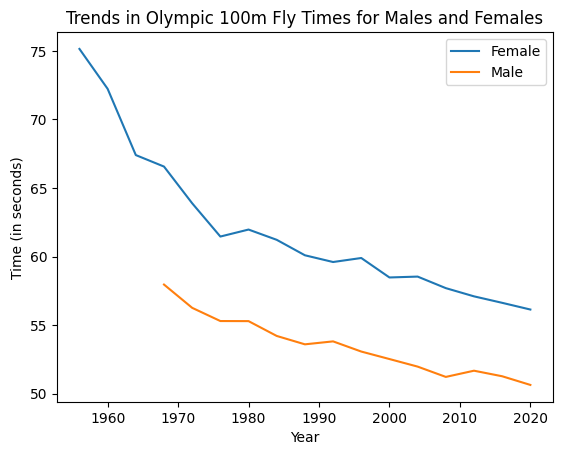

In [36]:
ax = df_fem_fly.plot.line(x="Year", y="Time")
df_male_fly.plot.line(x="Year", y="Time", ax=ax)
ax.set_ylabel("Time (in seconds)")
ax.set_title("Trends in Olympic 100m Fly Times for Males and Females")
ax.legend(["Female", "Male"])

Note: The 100m Butterfly event was added for men later on because they initially only had the 200m fly for men and the 100m was for women.

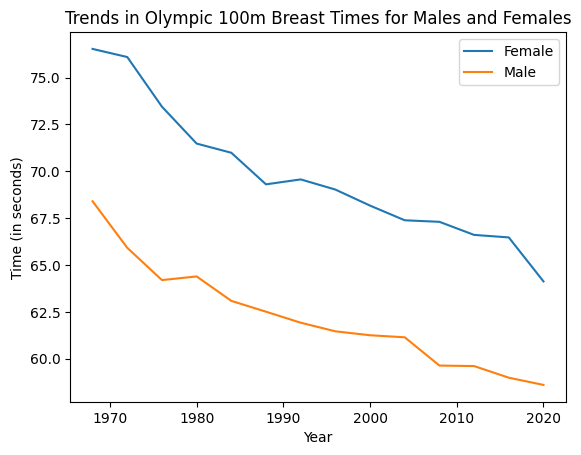

In [37]:
ax = df_fem_breast.plot.line(x="Year", y="Time")
df_male_breast.plot.line(x="Year", y="Time", ax=ax)
ax.set_ylabel("Time (in seconds)")
ax.set_title("Trends in Olympic 100m Breast Times for Males and Females")
ax.legend(["Female", "Male"])

#### Summary of Visualizations:
All four of these graphs show a significant negative trend across all the years for each 100m event. Men are also faster than women by at least 5 seconds for each event. It is also interesting to note that not every event existed at the beginning, for instance the 100m fly was added later on around 1960 for women and around 1970 for men.


# Section 4: Planning for Part II
Observations:
- I observed that there is a significant negative trend in times across all events, though the rate at which it is decreasing seems to slowing down.
- I observed that the average times for men are all faster than the average times for women.
- I observed that Team USA has had the most swimmers compete in the Olympics, and is also the country with the most gold medals.

Ideas:
- Can this data be used to predict times for each event based on year and stroke within each gender using a machine learning model?
- Can this data be used to predict the stroke of an event given a year and time within each gender using a machine learning model?

# Section 5: Data Science
The question I will choose to explore is whether I can use this data to predict the stroke of an event (within each gender) given a year and time using a machine learning model. I will answer this question by using the k-Nearest Neighbors classifier. I believe using the kNN classifier is a good choice because I think a supervised algorithm will be more accurate than an unsupervised classifier like k-means clustering. I will make two different models, one trained with the female swimmer data and one trained with the male swimmer data, so that the classifications will be more accurate. The independent variables will be year and time, and the dependent variable will be stroke.

In [ ]:
#Displaying the dataframe I will use for reference:
df_female

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time
32,Tokyo,2020,100m,Backstroke,0,Women,AUS,Kaylee Mckeown,57.47,1,57.47
33,Tokyo,2020,100m,Backstroke,0,Women,CAN,Kylie Masse,57.72,2,57.72
34,Tokyo,2020,100m,Backstroke,0,Women,USA,Regan Smith,58.05,3,58.05
35,Tokyo,2020,100m,Backstroke,0,Women,USA,Rhyan Elizabeth White,58.43,4,58.43
36,Tokyo,2020,100m,Backstroke,0,Women,AUS,Emily Seebohm,58.45,4,58.45
...,...,...,...,...,...,...,...,...,...,...,...
1228,Stockholm,1912,100m,Freestyle,0,Women,ANZ,Fanny Durack,00:01:22.200000,1,82.20
1229,Stockholm,1912,100m,Freestyle,0,Women,ANZ,Mina Wylie,00:01:25.400000,2,85.40
1230,Stockholm,1912,100m,Freestyle,0,Women,GBR,Jennie Fletcher,00:01:27.000000,3,87.00
1231,Stockholm,1912,100m,Freestyle,0,Women,GER,Grete Rosenberg,00:01:27.200000,4,87.20


I will use a 70/30 test/train split.

In [61]:
from sklearn.neighbors import KNeighborsClassifier
ind = ["Year", "Time"]
dep = "Stroke"
#Female Swimmers
train = df_female.sample(424) #Number of rows in df_female = 606 , 606 * 0.7 = 424
train

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time
1001,Melbourne,1956,100m,Freestyle,0,Women,AUS,Lorraine Joyce Crapp,00:01:02.300000,2,62.30
666,Moscow,1980,100m,Breaststroke,0,Women,DEN,Susanne Schultz Nielsson,00:01:11.160000,3,71.16
223,Beijing,2008,100m,Breaststroke,0,Women,JPN,Asami Kitagawa,00:01:08.430000,4,68.43
444,Atlanta,1996,100m,Freestyle,0,Women,GER,Franziska Van Almsick,55.590,4,55.59
171,London,2012,100m,Butterfly,0,Women,SWE,Sarah Sjostrom,57.170,4,57.17
...,...,...,...,...,...,...,...,...,...,...,...
605,Angeles,1984,100m,Breaststroke,0,Women,JPN,Hiroko Nagasaki,00:01:11.330000,4,71.33
1055,London,1948,100m,Backstroke,0,Women,NED,Greetje Gaillard,00:01:19.100000,4,79.10
56,Tokyo,2020,100m,Freestyle,0,Women,AUS,Emma Mckeon,51.96,1,51.96
265,Athens,2004,100m,Backstroke,0,Women,ZIM,Kirsty Leigh Coventry,00:01:00.500000,2,60.50


In [62]:
test = df_female[~df_female.index.isin(train.index)] #select rows not contained in the train dataframe
test

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time
40,Tokyo,2020,100m,Breaststroke,0,Women,USA,Lydia Jacoby,1:04.95,1,65.00
46,Tokyo,2020,100m,Breaststroke,0,Women,ITA,Martina Carraro,1:06.19,4,69.00
50,Tokyo,2020,100m,Butterfly,0,Women,AUS,Emma Mckeon,55.72,3,55.72
52,Tokyo,2020,100m,Butterfly,0,Women,SWE,Louise Hansson,56.22,4,56.22
53,Tokyo,2020,100m,Butterfly,0,Women,FRA,Marie Wattel,56.27,4,56.27
...,...,...,...,...,...,...,...,...,...,...,...
1174,Paris,1924,100m,Backstroke,0,Women,USA,Sybil Bauer,00:01:23.200000,1,83.20
1175,Paris,1924,100m,Backstroke,0,Women,GBR,Phyllis Harding,00:01:27.400000,2,87.40
1191,Paris,1924,100m,Freestyle,0,Women,GBR,Vera Tanner,00:01:20.800000,4,80.80
1205,Antwerp,1920,100m,Freestyle,0,Women,USA,Ethelda Bleibtrey,00:01:13.600000,3,73.60


In [72]:
fem_model = KNeighborsClassifier()
fem_model.fit(train[ind], train[dep])

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [64]:
#Test how well the model does
test["Predicted Stroke"] = fem_model.predict(test[ind])
test[["Stroke", "Predicted Stroke"]].head(20)

C:\Users\kaitl\AppData\Local\Temp\ipykernel_30468\736112908.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["Predicted Stroke"] = fem_model.predict(test[ind])


,Stroke,Predicted Stroke
40,Breaststroke,Breaststroke
46,Breaststroke,Breaststroke
50,Butterfly,Butterfly
52,Butterfly,Butterfly
53,Butterfly,Butterfly
57,Freestyle,Freestyle
58,Freestyle,Freestyle
73,Backstroke,Backstroke
74,Backstroke,Backstroke
76,Backstroke,Backstroke


It appears that the model does a strong job of accurately predicting the stroke of 100m events based off of a time and year for female swimmers!

In [66]:
#Displaying the dataframe for reference:
df_male

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1,51.98
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2,52.00
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3,52.19
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4,52.30
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4,52.51
...,...,...,...,...,...,...,...,...,...,...,...
1220,Stockholm,1912,100m,Freestyle,0,Men,USA,Duke Paoa Kahanamoku,00:01:03.400000,1,63.40
1221,Stockholm,1912,100m,Freestyle,0,Men,ANZ,Cecil Healy,00:01:04.600000,2,64.60
1222,Stockholm,1912,100m,Freestyle,0,Men,USA,Kenneth Huszagh,00:01:05.600000,3,65.60
1223,Stockholm,1912,100m,Freestyle,0,Men,GER,Kurt Bretting,00:01:05.800000,4,65.80


In [69]:
train = df_male.sample(410) #Number of rows in df_male = 586 , 586 * 0.7 = 410
train

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time
807,Munich,1972,100m,Butterfly,0,Men,AUS,Neil Rogers,57.900,4,57.90
465,Barcelona,1992,100m,Breaststroke,0,Men,HUN,Norbert Rozsa,00:01:01.680000,2,61.68
693,Moscow,1980,100m,Freestyle,0,Men,URS,Sergei Krasiuk,51.800,4,51.80
450,Barcelona,1992,100m,Backstroke,0,Men,USA,David Charles Berkoff,54.780,3,54.78
624,Angeles,1984,100m,Freestyle,0,Men,USA,Ambrose Iv Gaines,49.800,1,49.80
...,...,...,...,...,...,...,...,...,...,...,...
705,Montreal,1976,100m,Backstroke,0,Men,USA,Peter Drake Rocca,56.340,2,56.34
822,Munich,1972,100m,Freestyle,0,Men,FRA,Michel Rousseau,52.900,4,52.90
563,Seoul,1988,100m,Freestyle,0,Men,URS,Gennady Prigoda,49.750,4,49.75
850,City,1968,100m,Breaststroke,0,Men,URS,Nikolai Pankin,00:01:08.000000,2,68.00


In [70]:
test = df_male[~df_male.index.isin(train.index)]
test

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3,52.19
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4,52.51
6,Tokyo,2020,100m,Backstroke,0,Men,AUS,Mitchell Larkin,52.79,4,52.79
8,Tokyo,2020,100m,Breaststroke,0,Men,GBR,Adam Peaty,57.37,1,57.37
11,Tokyo,2020,100m,Breaststroke,0,Men,USA,Michael Andrew,58.84,4,58.84
...,...,...,...,...,...,...,...,...,...,...,...
1216,Stockholm,1912,100m,Backstroke,0,Men,GER,Otto Gross,00:01:25.800000,4,85.80
1220,Stockholm,1912,100m,Freestyle,0,Men,USA,Duke Paoa Kahanamoku,00:01:03.400000,1,63.40
1222,Stockholm,1912,100m,Freestyle,0,Men,USA,Kenneth Huszagh,00:01:05.600000,3,65.60
1223,Stockholm,1912,100m,Freestyle,0,Men,GER,Kurt Bretting,00:01:05.800000,4,65.80


In [71]:
#Male Swimmers
male_model = KNeighborsClassifier()
male_model.fit(train[ind], train[dep])

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [74]:
#Test how well the model does
test["Predicted Stroke"] = male_model.predict(test[ind])
test[["Stroke", "Predicted Stroke"]].head(20)

C:\Users\kaitl\AppData\Local\Temp\ipykernel_30468\3637485045.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["Predicted Stroke"] = male_model.predict(test[ind])


,Stroke,Predicted Stroke
2,Backstroke,Backstroke
4,Backstroke,Backstroke
6,Backstroke,Backstroke
8,Breaststroke,Breaststroke
11,Breaststroke,Breaststroke
12,Breaststroke,Breaststroke
16,Butterfly,Butterfly
19,Butterfly,Butterfly
22,Butterfly,Butterfly
24,Freestyle,Freestyle


It appears that this model also does a strong job of accurately predicted the strokes of 100m events based off of year and time for male swimmers!

#### Conclusion:
The answer is yes, I can make a reliable and accurate model that can predict the stroke of 100m events based off of year and time! This is helpful because it shows how each stroke has a different set of speeds. This can be used to better understand how fast Olympians were going for each stroke during a certain year -- for instance, if one were curious as to what stroke a speed of 59.0 seconds in a 100m event in the year 1972 would correspond to, they could use this model to predict it.

# Section 6: A Different Data Visualization
For this section, I will make box plots of the average speeds each year of each stroke for men and women to visualize the spread of the times across the years. I will use Matplotlib in order to plot two boxplots side by side.

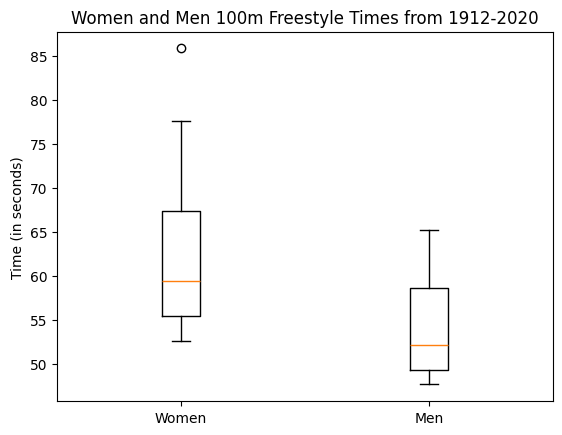

In [93]:
import matplotlib.pyplot as plt
#100m Freestyle
plt.boxplot([df_fem_free["Time"], df_male_free["Time"]], tick_labels=["Women", "Men"])
plt.title("Women and Men 100m Freestyle Times from 1912-2020")
plt.ylabel("Time (in seconds)")
plt.show()

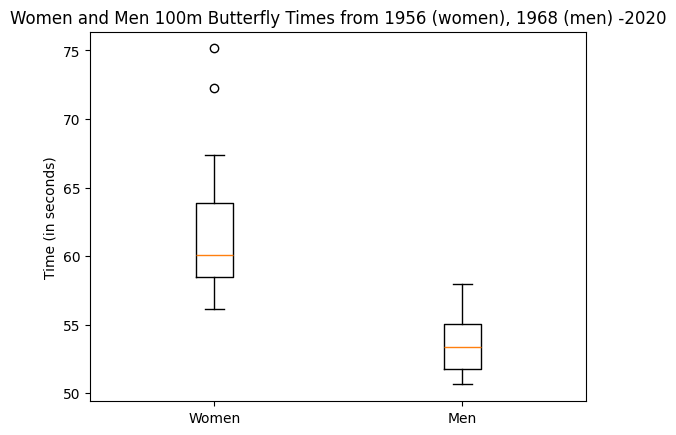

In [109]:
#100m Butterfly
plt.boxplot([df_fem_fly["Time"], df_male_fly["Time"]], tick_labels=["Women", "Men"])
plt.title("Women and Men 100m Butterfly Times from 1956 (women), 1968 (men) -2020")
plt.ylabel("Time (in seconds)")
plt.show()

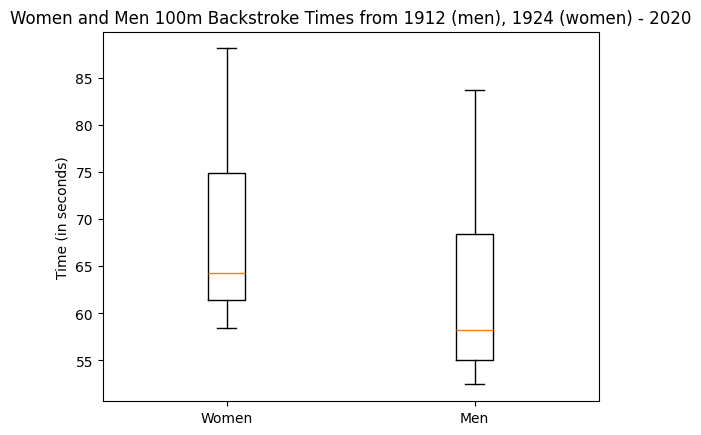

In [110]:
#100m Backstroke
plt.boxplot([df_fem_back["Time"], df_male_back["Time"]], tick_labels=["Women", "Men"])
plt.title("Women and Men 100m Backstroke Times from 1912 (men), 1924 (women) - 2020")
plt.ylabel("Time (in seconds)")
plt.show()

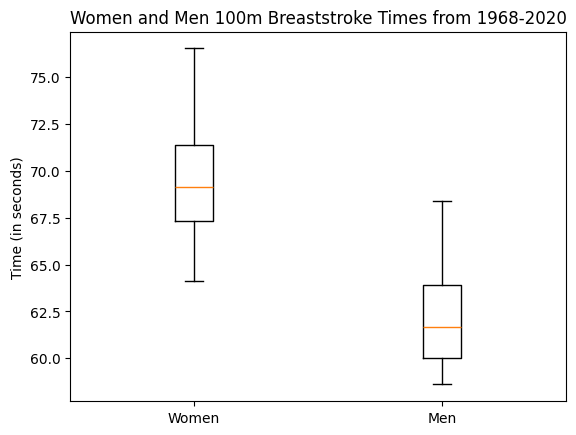

In [111]:
#100m Breaststroke
plt.boxplot([df_fem_breast["Time"], df_male_breast["Time"]], tick_labels=["Women", "Men"])
plt.title("Women and Men 100m Breaststroke Times from 1968-2020")
plt.ylabel("Time (in seconds)")
plt.show()

#### Summary of Boxplots:
These boxplots all show the trend of women's times being slower than the men's times. For all the events, at least 50% of the men's times are greater than all the women's times. This can be inferred by looking at where the median line lies on the men's boxplot in comparison to the women's boxplot (the median for men is greater than or equal to the minimum time for women on all the graphs). In addition, the women's times generally has more variability compared to the men's. For instance for the 100m freestyle and the 100m butterfly, the women's boxplot has outliers, but none of the men's boxplots have outliers.

# Section 7: Overall Summary

For this project, I used a dataset that contained all the timed results of each swimmer that swam the 100m Backstroke, Breaststroke, Butterfly, and Freestyle in the Olympics from 1912 to 2020. One key finding I discovered while diving into this dataset was that the average times for each event went down signficantly over time, showing a nonlinear, exponentially decreasing trend. This can be seen from the line graphs I plotted for each event in Section 3. For example, for the men's 100m freestyle, the average time in 1912 was 65.16 seconds, which continued to drop each year until reaching an average time of 47.635 seconds in 2020--a nearly 20 second difference! This trend is also apparent for the women: the average time in 1912 for the 100m freestyle was 85.84 seconds, and the average time in 2020 was 52.61 seconds, a more than 30 second difference!

Another key finding I discovered was that each stroke (backstroke, breaststroke, butterfly, and freestyle) has a different speed, which can be seen from the kNN model I developed in Section 5. The model was able to accurately categorize the strokes based off of year and time, which indicates that there are significant differences between the speeds of each stroke. The boxplots I made in Section 6 support this finding, as they indicate that freestyle is the fastest of the four strokes, followed by butterfly, backstroke, and then breaststroke. For instance, the median speed for the men's 100m freestyle is around 53 seconds, while the median speed for the men's 100m breaststroke is around 61 seconds.